Imports


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

generate synthetic training data

In [4]:
np.random.seed(42)
n_samples = 2000

# simulate normal machine behavior over time
time_index = np.arange(n_samples)

# base CPU: varies between 20-50% normally
cpu_base = 35 + 10 * np.sin(time_index / 100)

# add realistic noise
cpu_noise = np.random.normal(0, 5, n_samples)
cpu = cpu_base + cpu_noise

# inject anomalies at random positions (~5% of data)
anomaly_idx = np.random.choice(n_samples, size=100, replace=False)
cpu[anomaly_idx] += np.random.choice([-30, 40, 50, 60], size=100)

# clip to realistic range
cpu = np.clip(cpu, 0, 100)

# same for RAM
ram_base = 55 + 8 * np.sin(time_index / 150 + 1)
ram_noise = np.random.normal(0, 4, n_samples)
ram = ram_base + ram_noise
ram_anomaly_idx = np.random.choice(n_samples, size=80, replace=False)
ram[ram_anomaly_idx] += np.random.choice([-20, 30, 40], size=80)
ram = np.clip(ram, 0, 100)

df = pd.DataFrame({
    'cpu_percent': cpu,
    'ram_percent': ram,
    'timestamp':   time_index,
})

print(f"Dataset shape: {df.shape}")
print(df.describe())

Dataset shape: (2000, 3)
       cpu_percent  ram_percent    timestamp
count  2000.000000  2000.000000  2000.000000
mean     37.193287    56.009099   999.500000
std      13.220842     9.358302   577.494589
min       0.000000    22.522482     0.000000
25%      28.926581    49.730174   499.750000
50%      35.991581    55.513463   999.500000
75%      42.884630    61.195600  1499.250000
max     100.000000   100.000000  1999.000000


visualize the synthetic data

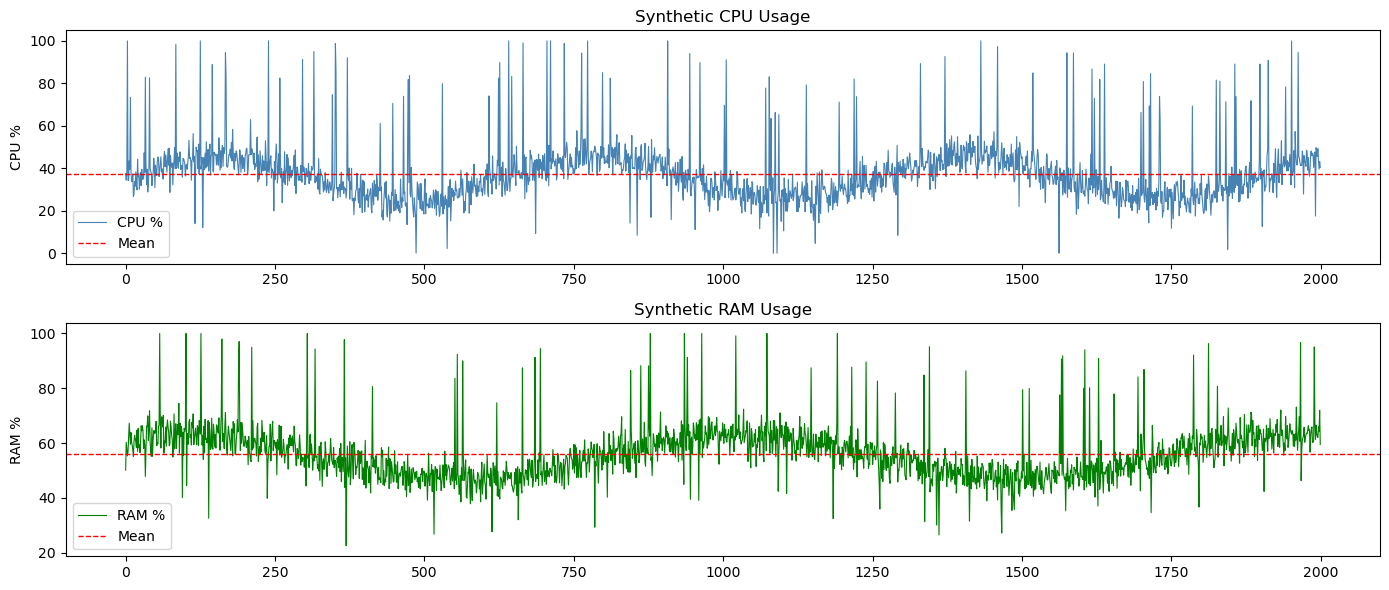

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(df['cpu_percent'], color='steelblue', linewidth=0.8, label='CPU %')
axes[0].axhline(df['cpu_percent'].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
axes[0].set_title('Synthetic CPU Usage')
axes[0].set_ylabel('CPU %')
axes[0].legend()

axes[1].plot(df['ram_percent'], color='green', linewidth=0.8, label='RAM %')
axes[1].axhline(df['ram_percent'].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
axes[1].set_title('Synthetic RAM Usage')
axes[1].set_ylabel('RAM %')
axes[1].legend()

plt.tight_layout()
plt.show()

build the anomaly detection model


In [11]:
class ZScoreAnomalyDetector:
    """
    Detects anomalies using rolling Z-score.
    A reading is anomalous if it deviates more than
    `threshold` standard deviations from the rolling mean.
    """

    def __init__(self, window=50, threshold=3.0):
        self.window    = window      # how many past readings to consider
        self.threshold = threshold   # how many std devs = anomaly
        self.stats     = {}          # stores mean + std per metric

    def fit(self, df):
        """Learn mean and std for each metric."""
        for col in ['cpu_percent', 'ram_percent']:
            self.stats[col] = {
                'mean': df[col].mean(),
                'std':  df[col].std(),
            }
        print("Model trained:")
        for metric, stat in self.stats.items():
            print(f"  {metric}: mean={stat['mean']:.1f}%, std={stat['std']:.1f}%")
        return self

    def score(self, metric, value):
        """Return Z-score for a single value."""
        stat = self.stats[metric]
        if stat['std'] == 0:
            return 0
        return abs(value - stat['mean']) / stat['std']

    def predict(self, metric, value):
        """
        Returns a dict with:
        - is_anomaly: bool
        - z_score: float
        - severity: 'normal' | 'warning' | 'critical'
        """
        z = self.score(metric, value)
        if z > self.threshold * 1.5:
            severity = 'critical'
        elif z > self.threshold:
            severity = 'warning'
        else:
            severity = 'normal'

        return {
            'is_anomaly': z > self.threshold,
            'z_score':    round(z, 2),
            'severity':   severity,
            'mean':       round(self.stats[metric]['mean'], 1),
            'std':        round(self.stats[metric]['std'], 1),
        }

detector = ZScoreAnomalyDetector(window=50, threshold=3.0)
detector.fit(df)

Model trained:
  cpu_percent: mean=37.2%, std=13.2%
  ram_percent: mean=56.0%, std=9.4%


 evaluate the model

In [14]:
# run predictions on entire dataset
results = []
for i, row in df.iterrows():
    cpu_pred = detector.predict('cpu_percent', row['cpu_percent'])
    ram_pred = detector.predict('ram_percent', row['ram_percent'])
    results.append({
        'timestamp':       i,
        'cpu':             row['cpu_percent'],
        'ram':             row['ram_percent'],
        'cpu_anomaly':     cpu_pred['is_anomaly'],
        'ram_anomaly':     ram_pred['is_anomaly'],
        'cpu_z':           cpu_pred['z_score'],
        'ram_z':           ram_pred['z_score'],
        'cpu_severity':    cpu_pred['severity'],
    })

results_df = pd.DataFrame(results)

cpu_anomalies = results_df[results_df['cpu_anomaly']]
ram_anomalies = results_df[results_df['ram_anomaly']]

print(f"Total samples   : {len(results_df)}")
print(f"CPU anomalies   : {len(cpu_anomalies)} ({len(cpu_anomalies)/len(results_df)*100:.1f}%)")
print(f"RAM anomalies   : {len(ram_anomalies)} ({len(ram_anomalies)/len(results_df)*100:.1f}%)")

Total samples   : 2000
CPU anomalies   : 58 (2.9%)
RAM anomalies   : 46 (2.3%)


visualize anomalies

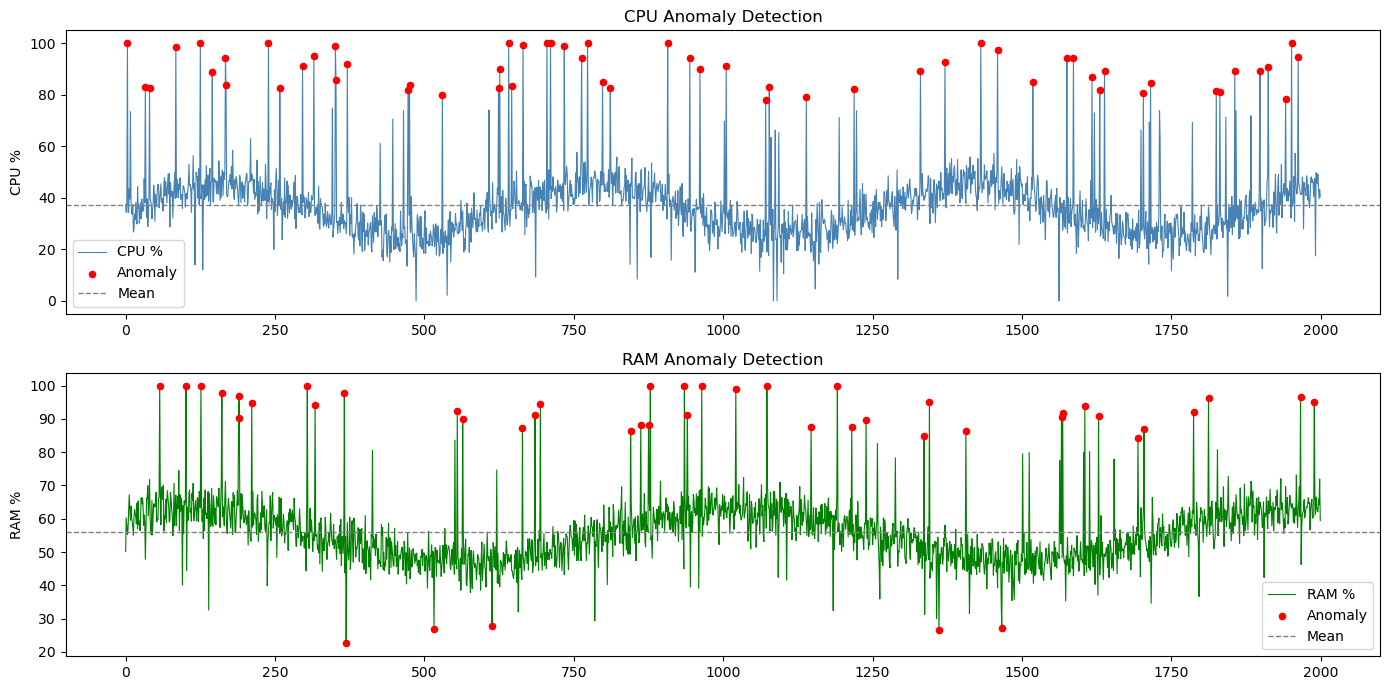

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# CPU
axes[0].plot(results_df['timestamp'], results_df['cpu'],
             color='steelblue', linewidth=0.8, label='CPU %')
axes[0].scatter(cpu_anomalies['timestamp'], cpu_anomalies['cpu'],
                color='red', s=20, zorder=5, label='Anomaly')
axes[0].axhline(detector.stats['cpu_percent']['mean'], color='gray',
                linestyle='--', linewidth=1, label='Mean')
axes[0].set_title('CPU Anomaly Detection')
axes[0].set_ylabel('CPU %')
axes[0].legend()

# RAM
axes[1].plot(results_df['timestamp'], results_df['ram'],
             color='green', linewidth=0.8, label='RAM %')
axes[1].scatter(ram_anomalies['timestamp'], ram_anomalies['ram'],
                color='red', s=20, zorder=5, label='Anomaly')
axes[1].axhline(detector.stats['ram_percent']['mean'], color='gray',
                linestyle='--', linewidth=1, label='Mean')
axes[1].set_title('RAM Anomaly Detection')
axes[1].set_ylabel('RAM %')
axes[1].legend()

plt.tight_layout()
plt.show()

test with a single live value

In [20]:
# simulate what Django will send
test_cases = [
    ('cpu_percent', 38.0),   # normal
    ('cpu_percent', 92.0),   # anomaly
    ('ram_percent', 58.0),   # normal
    ('ram_percent', 97.0),   # anomaly
]

print("Single value predictions:")
print("-" * 50)
for metric, value in test_cases:
    result = detector.predict(metric, value)
    status = "🔴 ANOMALY" if result['is_anomaly'] else "🟢 normal"
    print(f"{metric:15} = {value:5.1f}%  →  {status}  (z={result['z_score']})")

Single value predictions:
--------------------------------------------------
cpu_percent     =  38.0%  →  🟢 normal  (z=0.06)
cpu_percent     =  92.0%  →  🔴 ANOMALY  (z=4.15)
ram_percent     =  58.0%  →  🟢 normal  (z=0.21)
ram_percent     =  97.0%  →  🔴 ANOMALY  (z=4.38)


 save the model


In [23]:
os.makedirs('models', exist_ok=True)
joblib.dump(detector, 'models/anomaly_model.pkl')
print("Model saved → ml/models/anomaly_model.pkl")

# verify it loads correctly
loaded = joblib.load('models/anomaly_model.pkl')
test = loaded.predict('cpu_percent', 95.0)
print(f"Verification: CPU 95% → {test}")

Model saved → ml/models/anomaly_model.pkl
Verification: CPU 95% → {'is_anomaly': True, 'z_score': 4.37, 'severity': 'warning', 'mean': 37.2, 'std': 13.2}


In [27]:
# define the class identically to monitor/anomaly_detector.py
# this makes pickle save it with the correct module reference

import sys
sys.path.insert(0, r'C:\Users\USER\Desktop\endpoint_monitor\monitor')

# import directly from the file as a proper module
from anomaly_detector import ZScoreAnomalyDetector

# retrain
detector2 = ZScoreAnomalyDetector(window=50, threshold=3.0)
detector2.fit(df)

# overwrite
joblib.dump(detector2, 'models/anomaly_model.pkl')
print("Model re-saved correctly")

# verify
loaded = joblib.load('models/anomaly_model.pkl')
test   = loaded.predict('cpu_percent', 95.0)
print(f"Verification: {test}")

Model re-saved correctly
Verification: {'is_anomaly': True, 'z_score': 4.37, 'severity': 'warning', 'mean': 37.2, 'std': 13.2}


In [29]:
import json

# extract just the data from the trained model
model_data = {
    'window':    detector.window,
    'threshold': detector.threshold,
    'stats':     detector.stats
}

with open('models/anomaly_model.json', 'w') as f:
    json.dump(model_data, f, indent=2)

print("Saved as JSON:")
print(json.dumps(model_data, indent=2))

Saved as JSON:
{
  "window": 50,
  "threshold": 3.0,
  "stats": {
    "cpu_percent": {
      "mean": 37.19328669820692,
      "std": 13.22084153618132
    },
    "ram_percent": {
      "mean": 56.00909884509776,
      "std": 9.358301889571685
    }
  }
}
